In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Data Exploration Notebook")

Data Exploration Notebook


In [2]:
data = pd.read_csv('../data/updated_ckd_dataset_with_stages.csv')

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {list(data.columns)}")
print(f"\nFirst 5 rows:")
data.head()

Dataset shape: (4000, 23)

Columns: ['serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana', 'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure', 'physical_activity', 'diet', 'water_intake', 'smoking', 'alcohol', 'painkiller_usage', 'family_history', 'weight_changes', 'stress_level', 'months', 'cluster', 'ckd_pred', 'ckd_stage']

First 5 rows:


,serum_creatinine,gfr,bun,serum_calcium,ana,c3_c4,hematuria,oxalate_levels,urine_ph,blood_pressure,...,smoking,alcohol,painkiller_usage,family_history,weight_changes,stress_level,months,cluster,ckd_pred,ckd_stage
0,0.683683,32.946784,7.553739,10.039896,0,138.204989,0,2.878164,7.864308,115.224217,...,yes,daily,no,yes,stable,low,10,5,CKD,3
1,3.809044,32.685035,141.347494,8.330543,1,24.282343,1,4.767639,4.920015,130.143900,...,yes,daily,no,yes,loss,moderate,1,2,CKD,3
2,1.143827,2.079805,15.979104,9.419229,0,163.970666,0,1.818613,6.188115,98.026072,...,no,daily,no,no,stable,moderate,4,6,CKD,5
3,4.804657,109.871407,53.307333,7.556631,1,71.056846,1,4.051686,5.278607,142.166650,...,no,never,yes,yes,stable,high,9,2,CKD,1
4,4.920235,42.214590,134.182157,7.289379,1,23.384639,1,3.240920,4.862923,151.962572,...,no,occasionally,yes,no,gain,high,7,2,CKD,3


Target distribution (ckd_pred):
ckd_pred
CKD       3875
No CKD     125
Name: count, dtype: int64


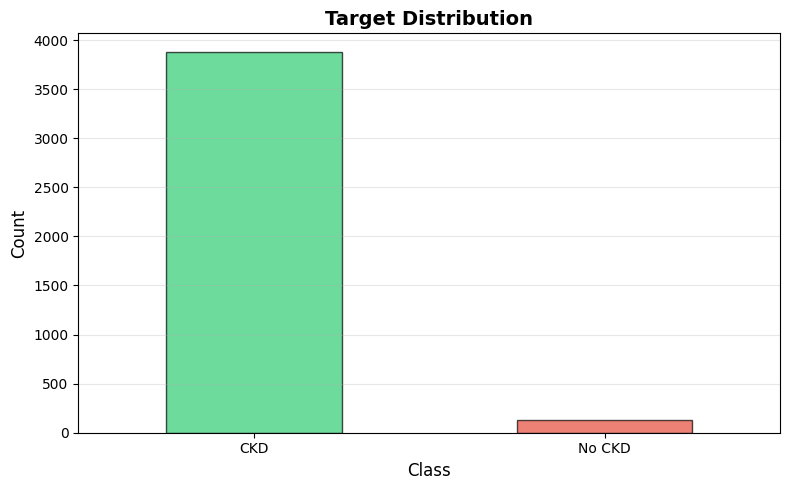

In [3]:
target_col = 'ckd_pred'

print(f"Target distribution ({target_col}):")
print(data[target_col].value_counts())

# Visualize
plt.figure(figsize=(8, 5))
data[target_col].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
plt.title('Target Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
print("Numeric Feature Statistics:")
print(data.describe())

print("\nMissing Values:")
missing = data.isnull().sum()
print(missing[missing > 0])

Numeric Feature Statistics:
       serum_creatinine          gfr          bun  serum_calcium          ana  \
count       4000.000000  4000.000000  4000.000000    4000.000000  4000.000000   
mean           1.551423    51.735449    39.346088       8.537530     0.300000   
std            1.217478    34.389322    42.495106       1.403631     0.458315   
min            0.500273     0.021317     7.000920       5.002407     0.000000   
25%            0.758924    20.263808    11.632573       7.810761     0.000000   
50%            0.995209    50.054933    16.296667       8.982200     0.000000   
75%            2.065796    80.258482    67.090486       9.583627     1.000000   
max            4.994009   119.923482   149.999395      10.199344     1.000000   

             c3_c4    hematuria  oxalate_levels     urine_ph  blood_pressure  \
count  4000.000000  4000.000000     4000.000000  4000.000000     4000.000000   
mean    109.757723     0.300000        2.624439     6.394566      119.747060   
st

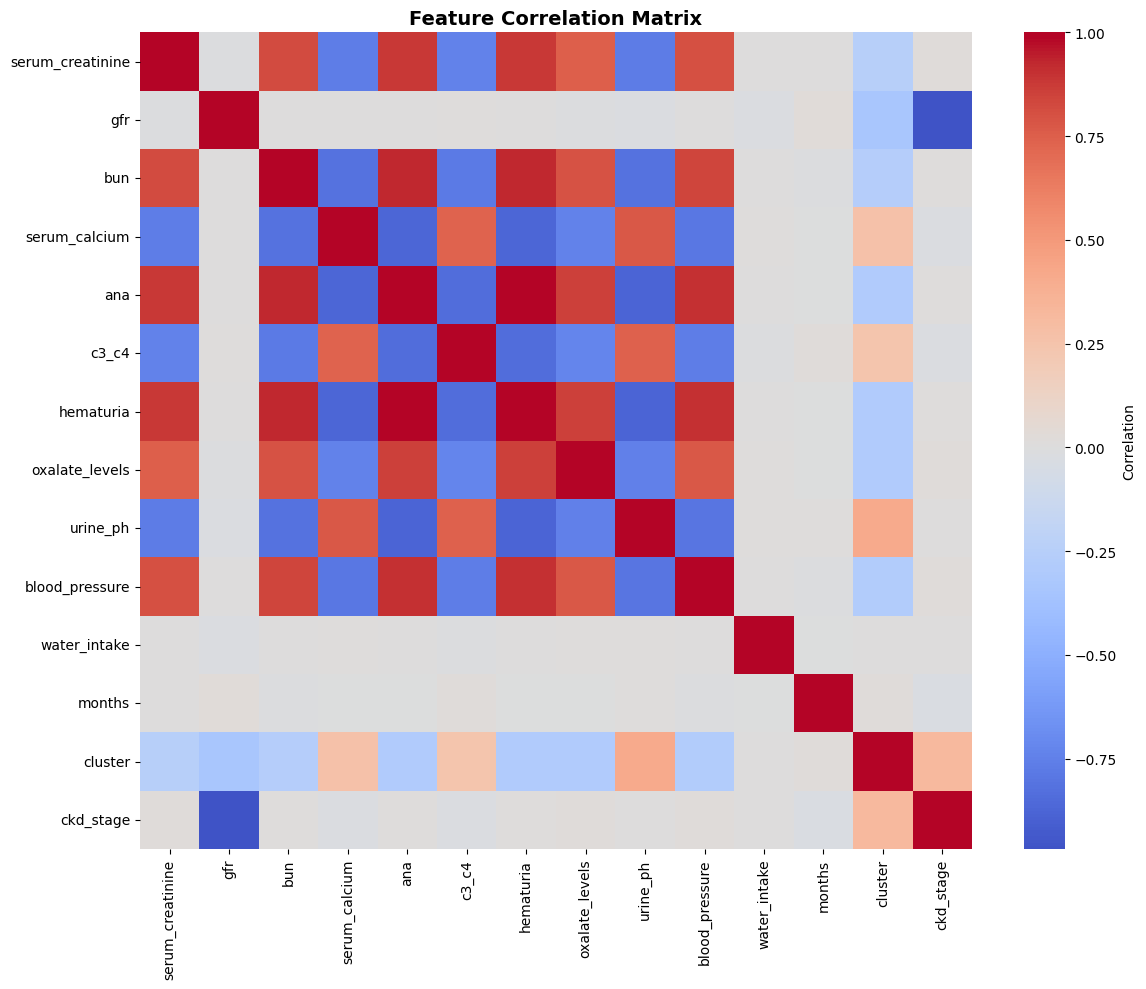

In [5]:
# Select numeric columns only
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 10))
    corr_matrix = data[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
                cbar_kws={'label': 'Correlation'})
    plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features for correlation matrix")

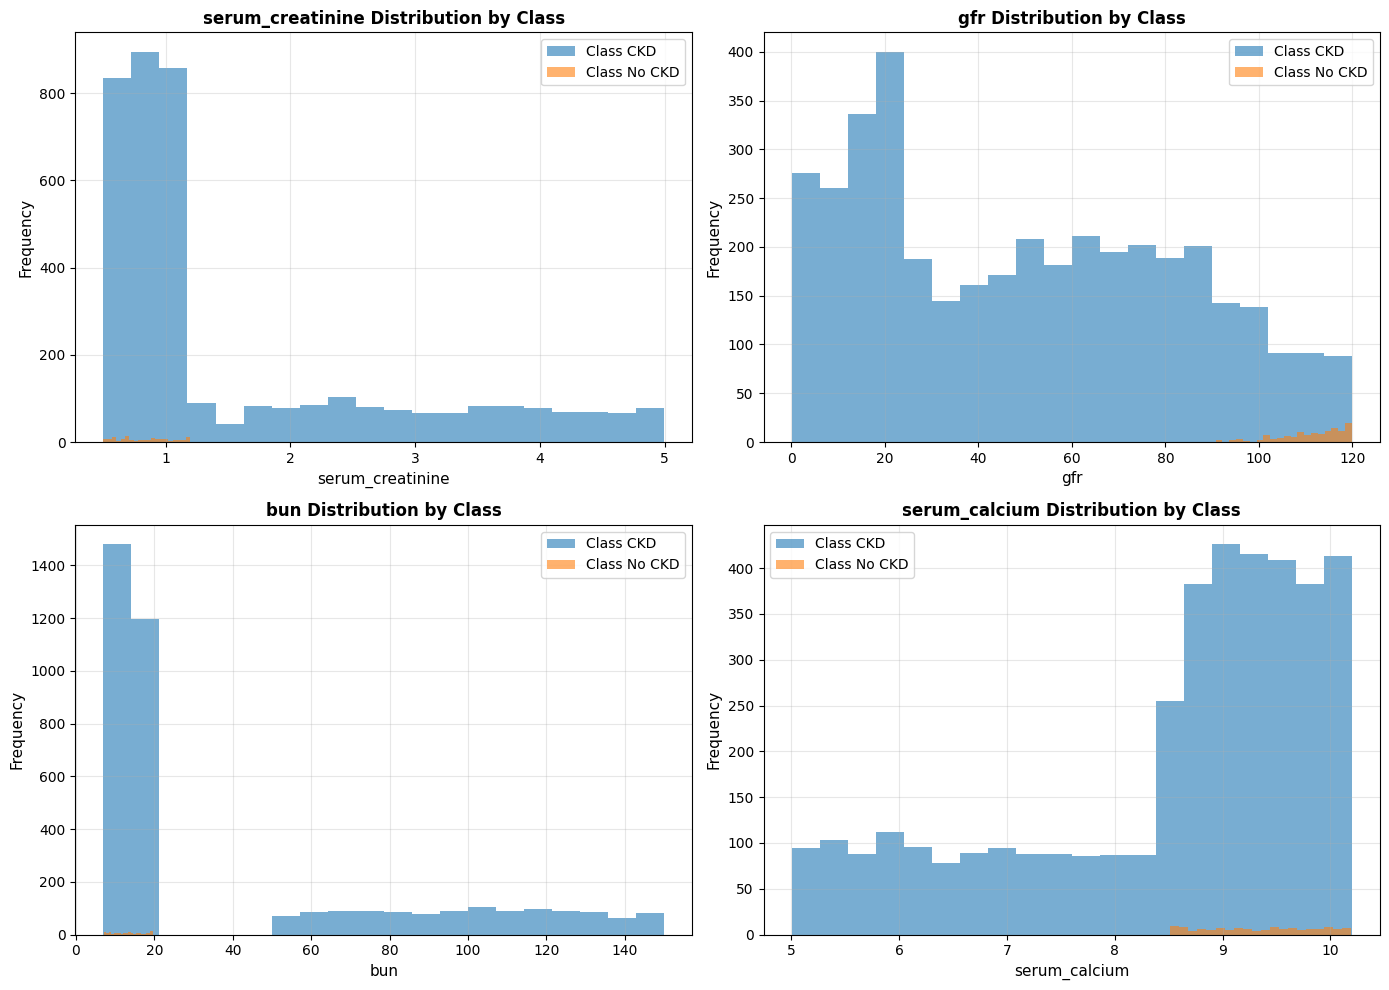

In [6]:
# Pick a few important numeric features
important_features = numeric_cols[:min(4, len(numeric_cols))]

if len(important_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(important_features):
        if idx < len(axes):
            for cls in data[target_col].unique():
                subset = data[data[target_col] == cls][feature].dropna()
                axes[idx].hist(subset, alpha=0.6, label=f'Class {cls}', bins=20)
            
            axes[idx].set_xlabel(feature, fontsize=11)
            axes[idx].set_ylabel('Frequency', fontsize=11)
            axes[idx].set_title(f'{feature} Distribution by Class', fontsize=12, fontweight='bold')
            axes[idx].legend()
            axes[idx].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [7]:
print("\nDataset Summary:")
print(f"Total samples: {len(data)}")
print(f"Total features: {data.shape[1] - 1}")  # Exclude target
print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(data.select_dtypes(include=['object']).columns)}")
print(f"\nClass balance:")
for cls, count in data[target_col].value_counts().items():
    pct = 100 * count / len(data)
    print(f"  Class {cls}: {count} ({pct:.1f}%)")


Dataset Summary:
Total samples: 4000
Total features: 22
Numeric features: 14
Categorical features: 9

Class balance:
  Class CKD: 3875 (96.9%)
  Class No CKD: 125 (3.1%)
